# EDA Inicial — Cancelaciones de reservas hoteleras

- **Proyecto:** Práctica Final · Machine Learning y Deep Learning
- **Integrantes:** Juan Martínez Fraile · Otra persona la que sea
- **Máster:** Inteligencia Artificial, Cloud Computing y DevOps · PontIA.tech
- **Fase:** Análisis Exploratorio de Datos

---

## Objetivo

Realizar un análisis exploratorio del dataset de reservas hoteleras para:

1. Comprender la estructura y calidad de los datos.
2. Identificar problemas de modelado (data leakage, nulos, outliers, desbalanceo).
3. Justificar las decisiones de preprocesamiento y modelado de fases posteriores.
4. Seleccionar la métrica principal de evaluación.

## Temas a tratar

0. Configuración del notebook
1. Carga inicial y vista general de los datos
2. Análisis de la variable objetivo (`is_canceled`)
3. Estadísticas de variables numéricas
4. Estadísticas de variables categóricas
5. Análisis de nulos y valores especiales
6. Detección de data leakage
7. Análisis bivariado y correlaciones
8. Resumen de decisiones para la fase de preprocesamiento

## 0. Configuración del notebook

Importamos las librerías necesarias y definimos constantes/funciones que usaremos a lo largo del análisis.

### Importación de librerías

In [3]:
"""Importación de librerías necesarias para el análisis exploratorio."""

# Standard library
from pathlib import Path

# Análisis y manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

# Configuración global de visualización
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Librerías importadas correctamente.")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

Librerías importadas correctamente.
pandas: 2.2.3
numpy: 1.26.4


### Definición de constantes

In [4]:
"""Constantes utilizadas a lo largo del análisis exploratorio."""

# === Rutas ===
# Path(__vsc_ipynb_file__) no existe; usamos la raíz del proyecto como referencia.
# Como el notebook está en notebooks/exploracion/, subimos dos niveles a la raíz.
PATH_PROYECTO = Path.cwd().parents[1] if "notebooks" in str(Path.cwd()) else Path.cwd()
PATH_DATA_RAW = PATH_PROYECTO / "data" / "raw"
PATH_DATA_PROCESSED = PATH_PROYECTO / "data" / "processed"
PATH_OUTPUTS = PATH_PROYECTO / "outputs"

PATH_DATASET = PATH_DATA_RAW / "dataset_practica_final.csv"

# === Configuración del análisis ===
SEED = 42  # Semilla para reproducibilidad
COLOR_PALETTE = ["#1f77b4", "#ff7f0e"]  # Azul (no cancelado) / Naranja (cancelado)
TARGET_COLUMN = "is_canceled"

# Verificación visual
print(f"Raíz del proyecto:  {PATH_PROYECTO}")
print(f"Dataset:            {PATH_DATASET}")
print(f"¿Dataset existe?:   {PATH_DATASET.exists()}")
print(f"Tamaño del archivo: {PATH_DATASET.stat().st_size / 1024 / 1024:.2f} MB")

Raíz del proyecto:  c:\Juan\Pontia\ML\practica-final-ml\practica-final-ml
Dataset:            c:\Juan\Pontia\ML\practica-final-ml\practica-final-ml\data\raw\dataset_practica_final.csv
¿Dataset existe?:   True
Tamaño del archivo: 16.07 MB


### Definición de funciones

In [5]:
"""Funciones de ayuda reutilizables en todo el análisis exploratorio."""

from typing import Optional


def resumen_df(df: pd.DataFrame) -> pd.DataFrame:
    """Devuelve un resumen compacto de cada columna de un DataFrame.

    Para cada columna calcula tipo, número de valores únicos, número y porcentaje
    de nulos, y una muestra de valores. Es la primera vista útil tras cargar
    cualquier dataset nuevo.

    Args:
        df (pd.DataFrame): DataFrame a inspeccionar.

    Returns:
        pd.DataFrame: Tabla con una fila por columna del DataFrame original.

    Example:
        >>> resumen_df(df).head()
    """
    resumen = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_unicos": df.nunique(),
        "n_nulos": df.isnull().sum(),
        "pct_nulos": (df.isnull().sum() / len(df) * 100).round(2),
        "ejemplos": [df[col].dropna().unique()[:3].tolist() for col in df.columns],
    })
    return resumen.sort_values("pct_nulos", ascending=False)


def plot_distribucion_categorica(
    df: pd.DataFrame,
    columna: str,
    hue: Optional[str] = None,
    top_n: Optional[int] = None,
    figsize: tuple = (10, 5),
    title: Optional[str] = None,
) -> None:
    """Visualiza la distribución de una variable categórica con conteos.

    Útil para entender la composición de variables como `hotel`, `market_segment`
    o `country`. Si se pasa `hue`, descompone cada barra por la variable indicada
    (típicamente la variable objetivo).

    Args:
        df (pd.DataFrame): DataFrame con los datos.
        columna (str): Nombre de la columna categórica a visualizar.
        hue (Optional[str]): Variable secundaria para descomponer (ej. el target).
        top_n (Optional[int]): Si se indica, muestra solo las `top_n` categorías más frecuentes.
        figsize (tuple): Tamaño de la figura (ancho, alto).
        title (Optional[str]): Título personalizado. Por defecto se genera automáticamente.

    Returns:
        None: La función dibuja directamente con matplotlib/seaborn.
    """
    plt.figure(figsize=figsize)

    # Filtrar a top_n si aplica
    if top_n is not None:
        top_categorias = df[columna].value_counts().head(top_n).index
        df_plot = df[df[columna].isin(top_categorias)]
        orden = top_categorias
    else:
        df_plot = df
        orden = df[columna].value_counts().index

    sns.countplot(
        data=df_plot,
        y=columna,
        hue=hue,
        order=orden,
        palette=COLOR_PALETTE if hue == TARGET_COLUMN else "deep",
    )

    if title is None:
        title = f"Distribución de '{columna}'"
        if hue:
            title += f" por '{hue}'"
        if top_n:
            title += f" (top {top_n})"

    plt.title(title)
    plt.xlabel("Número de reservas")
    plt.tight_layout()
    plt.show()


def plot_distribucion_numerica(
    df: pd.DataFrame,
    columna: str,
    hue: Optional[str] = None,
    bins: int = 50,
    figsize: tuple = (12, 4),
) -> None:
    """Visualiza histograma + boxplot de una variable numérica.

    Combina dos vistas complementarias: el histograma muestra la forma de la distribución,
    el boxplot muestra mediana, cuartiles y outliers. Si se pasa `hue`, separa por clases.

    Args:
        df (pd.DataFrame): DataFrame con los datos.
        columna (str): Nombre de la columna numérica.
        hue (Optional[str]): Variable categórica para separar las distribuciones.
        bins (int): Número de bins del histograma.
        figsize (tuple): Tamaño de la figura.

    Returns:
        None
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Histograma
    sns.histplot(
        data=df,
        x=columna,
        hue=hue,
        bins=bins,
        ax=axes[0],
        palette=COLOR_PALETTE if hue == TARGET_COLUMN else None,
        kde=True,
    )
    axes[0].set_title(f"Histograma de '{columna}'")

    # Boxplot
    if hue:
        sns.boxplot(
            data=df,
            x=hue,
            y=columna,
            ax=axes[1],
            palette=COLOR_PALETTE if hue == TARGET_COLUMN else None,
        )
        axes[1].set_title(f"Boxplot de '{columna}' por '{hue}'")
    else:
        sns.boxplot(data=df, x=columna, ax=axes[1])
        axes[1].set_title(f"Boxplot de '{columna}'")

    plt.tight_layout()
    plt.show()


print("Funciones helper definidas correctamente.")

Funciones helper definidas correctamente.


## 1. Carga inicial y vista general de los datos

En esta sección cargamos el dataset desde `data/raw/` y obtenemos una **primera fotografía** de su estructura:

- Dimensiones (filas, columnas).
- Tipos de datos por columna.
- Muestras de las primeras y últimas filas.
- Estadísticas descriptivas básicas.
- Detección de duplicados.

El objetivo es **no tomar decisiones todavía**, solo observar.

### 1.1. Lectura del dataset

In [6]:
"""Carga del dataset desde data/raw/."""

df = pd.read_csv(PATH_DATASET)

print(f"Dataset cargado: {PATH_DATASET.name}")
print(f"Dimensiones:      {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria ocupada:  {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

Dataset cargado: dataset_practica_final.csv
Dimensiones:      119,390 filas × 32 columnas
Memoria ocupada:  104.83 MB


### 1.2. Vista previa de los datos

Inspeccionamos las primeras y últimas filas para entender la "pinta" de las columnas:
qué tipos de valores contienen, si hay patrones visibles, qué columnas parecen
identificadores y cuáles parecen claramente numéricas o categóricas.

In [7]:
"""Primeras filas del DataFrame."""

df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,0.0,0,FB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,D,D,0,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [8]:
"""Últimas filas del DataFrame."""

df.tail(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


### 1.3. Tipos de datos y estructura

Inspeccionamos los tipos de cada columna. Buscamos:

- Columnas numéricas (int/float).
- Columnas categóricas (object).
- Columnas que parecen numéricas pero podrían ser categóricas disfrazadas (`agent`, `company`, `is_repeated_guest`).
- Columnas con tipo incorrecto (ej. una fecha guardada como string).

In [9]:
"""Información de tipos y nulos por columna."""

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [10]:
"""Resumen compacto con ejemplos por columna."""

resumen_df(df)

,tipo,n_unicos,n_nulos,pct_nulos,ejemplos
company,float64,352,112593,94.31,"[110.0, 113.0, 270.0]"
agent,float64,333,16340,13.69,"[304.0, 240.0, 303.0]"
country,object,177,488,0.41,"[PRT, GBR, USA]"
hotel,object,2,0,0.00,"[Resort Hotel, City Hotel]"
previous_cancellations,int64,15,0,0.00,"[0, 1, 2]"
reservation_status,object,3,0,0.00,"[Check-Out, Canceled, No-Show]"
total_of_special_requests,int64,6,0,0.00,"[0, 1, 3]"
required_car_parking_spaces,int64,5,0,0.00,"[0, 1, 2]"
adr,float64,8879,0,0.00,"[0.0, 75.0, 98.0]"
customer_type,object,4,0,0.00,"[Transient, Contract, Transient-Party]"


### 1.4. Estadísticas descriptivas

Para las variables numéricas observamos rango, media, mediana, mínimos y máximos.
Esto nos permite detectar:

- Valores imposibles (ej. una reserva con 0 adultos, 0 niños y 0 bebés).
- Outliers extremos (ej. `lead_time` de 700 días o más).
- Escalas muy diferentes entre variables (importante para futuros modelos con regularización).

In [11]:
"""Estadísticas descriptivas de las variables numéricas."""

df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.37,0.48,0.00,0.00,0.00,1.0,1.0
lead_time,119390.0,104.01,106.86,0.00,18.00,69.00,160.0,737.0
arrival_date_year,119390.0,2016.16,0.71,2015.00,2016.00,2016.00,2017.0,2017.0
arrival_date_week_number,119390.0,27.17,13.61,1.00,16.00,28.00,38.0,53.0
arrival_date_day_of_month,119390.0,15.80,8.78,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,119390.0,0.93,1.00,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119390.0,2.50,1.91,0.00,1.00,2.00,3.0,50.0
adults,119390.0,1.86,0.58,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.10,0.40,0.00,0.00,0.00,0.0,10.0
babies,119390.0,0.01,0.10,0.00,0.00,0.00,0.0,10.0


### 1.5. Detección de duplicados

Comprobamos si hay filas exactamente duplicadas. En reservas hoteleras esto puede pasar
por errores de captura o por reservas auténticamente repetidas (mismo cliente, mismas
fechas). Si hay muchos duplicados deberíamos analizarlos antes de tirarlos.

In [12]:
"""Detección de filas duplicadas."""

n_duplicados = df.duplicated().sum()
pct_duplicados = (n_duplicados / len(df)) * 100

print(f"Filas duplicadas: {n_duplicados:,} ({pct_duplicados:.2f}%)")

Filas duplicadas: 31,994 (26.80%)


In [13]:
"""Investigación de las filas duplicadas."""

# Coger las primeras 6 filas marcadas como duplicadas
duplicados_ejemplo = df[df.duplicated(keep=False)].head(6)
duplicados_ejemplo

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07


### 1.6. Resumen de la Sección 1

**Lo que hemos descubierto:**

- Dataset: **119.390 filas × 32 columnas**, cubre **3 años** (2015–2017).
- Tipos: ~16 numéricas + ~12 categóricas + ~4 floats.
- **Nulos**: `company` (~94%, inservible), `agent` (~13.7%), `country` (~0.4%), `children` (despreciable).
- **Valores anómalos** detectados:
  - `adr` puede ser negativo y llegar a 5400 (outliers extremos).
  - `adults` con max 55 (probable error de captura).
  - Hay duplicados (~25%) pero son **reservas legítimamente repetidas**, no las eliminaremos.
- Variable objetivo: `is_canceled`, binaria. Analizada en detalle en la sección 2.

Pendiente para la Sección 2: estudiar a fondo `is_canceled` (balance de clases, distribución temporal, métrica de evaluación).

## 2. Análisis de la variable objetivo (`is_canceled`)

La variable objetivo de este problema es **`is_canceled`**:

- `0` → la reserva se completó (cliente hizo check-in y se alojó).
- `1` → la reserva fue cancelada por el cliente.

En esta sección estudiamos:

- El balance de clases (¿es un problema desequilibrado?).
- La distribución temporal del target (¿hay tendencia o estacionalidad?).
- La elección de **métrica principal** de evaluación.
- La política de balanceo a aplicar (o no) en preprocesamiento.

De este análisis salen decisiones que condicionan todas las fases posteriores.

### 2.1. Balance de clases

Calculamos la frecuencia absoluta y relativa de cada clase. Esto nos dice
si tenemos un problema **balanceado** (clases similares) o **desbalanceado**
(una clase mucho más frecuente que otra).

In [14]:
"""Frecuencia absoluta y relativa de la variable objetivo."""

conteo = df[TARGET_COLUMN].value_counts()
porcentaje = df[TARGET_COLUMN].value_counts(normalize=True) * 100

resumen_target = pd.DataFrame({
    "n_reservas": conteo,
    "porcentaje": porcentaje.round(2),
})
resumen_target.index = ["No cancelado (0)", "Cancelado (1)"]
resumen_target

,n_reservas,porcentaje
No cancelado (0),75166,62.96
Cancelado (1),44224,37.04


C:\Users\juanm\AppData\Local\Temp\ipykernel_20184\1736053126.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\juanm\AppData\Local\Temp\ipykernel_20184\1736053126.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["No cancelado (0)", "Cancelado (1)"])


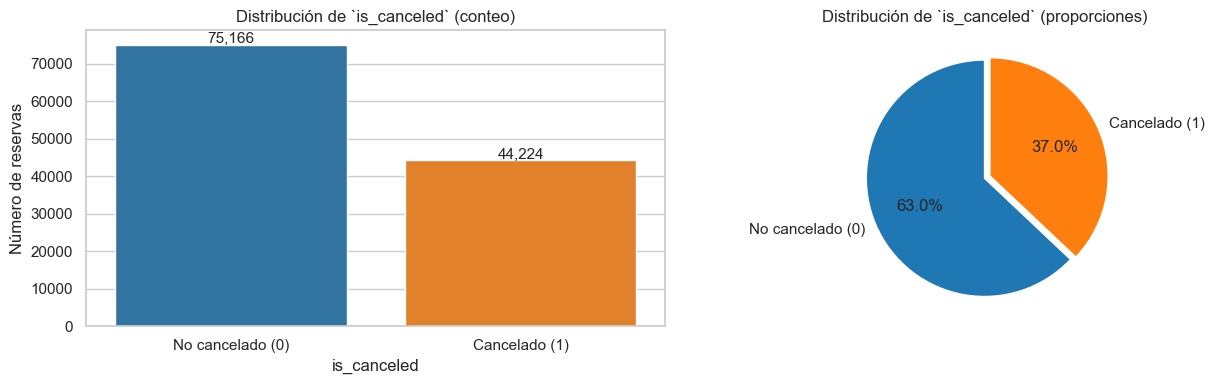

In [15]:
"""Visualización del balance de clases."""

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Gráfico 1: barras absolutas
sns.countplot(
    data=df,
    x=TARGET_COLUMN,
    palette=COLOR_PALETTE,
    ax=ax[0],
)
ax[0].set_title("Distribución de `is_canceled` (conteo)")
ax[0].set_xlabel("is_canceled")
ax[0].set_ylabel("Número de reservas")
ax[0].set_xticklabels(["No cancelado (0)", "Cancelado (1)"])

# Añadir conteos sobre cada barra
for patch in ax[0].patches:
    altura = patch.get_height()
    ax[0].text(
        patch.get_x() + patch.get_width() / 2,
        altura + 500,
        f"{int(altura):,}",
        ha="center",
        fontsize=11,
    )

# Gráfico 2: porcentajes
porcentajes = df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100
ax[1].pie(
    porcentajes,
    labels=["No cancelado (0)", "Cancelado (1)"],
    colors=COLOR_PALETTE,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0, 0.05),  # Separar ligeramente la clase positiva
)
ax[1].set_title("Distribución de `is_canceled` (proporciones)")

plt.tight_layout()
plt.show()

**Observaciones sobre el balance:**

- La clase mayoritaria (0, no cancelado) representa ~63%.
- La clase minoritaria (1, cancelado) representa ~37%.
- **NO es un problema de clases extremadamente desbalanceado** (tipo fraude 99/1).
  Pero tampoco está perfectamente balanceado (50/50).

**Implicaciones para modelado:**

- **No bastará con `accuracy`** como métrica principal: un modelo mal entrenado que prediga
  siempre 0 obtendría ~63% accuracy sin haber aprendido nada útil.
- **Es recomendable usar `stratify`** en `train_test_split` para mantener la proporción
  ~63/37 en ambos conjuntos.
- El balanceo (SMOTE / class_weight) es **opcional** en este caso; lo probaremos
  como bonus para ver si mejora la métrica.

### 2.2. Distribución temporal del target

Observamos cómo varía la tasa de cancelación a lo largo del tiempo. Si hubiera
tendencia o estacionalidad fuerte, deberíamos:

- Plantearnos un split train/test **cronológico** en lugar de aleatorio.
- Considerar añadir variables temporales (mes, día de la semana) en el preprocesamiento.

El dataset cubre **2015–2017** (3 años de reservas).

In [16]:
"""Tasa de cancelación por año."""

tasa_por_año = (
    df.groupby("arrival_date_year")[TARGET_COLUMN]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "n_reservas",
        "sum": "n_canceladas",
        "mean": "tasa_cancelacion",
    })
)
tasa_por_año["tasa_cancelacion"] = (tasa_por_año["tasa_cancelacion"] * 100).round(2)
tasa_por_año

,n_reservas,n_canceladas,tasa_cancelacion
arrival_date_year,,,
2015,21996,8142,37.02
2016,56707,20337,35.86
2017,40687,15745,38.70


C:\Users\juanm\AppData\Local\Temp\ipykernel_20184\3714869262.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


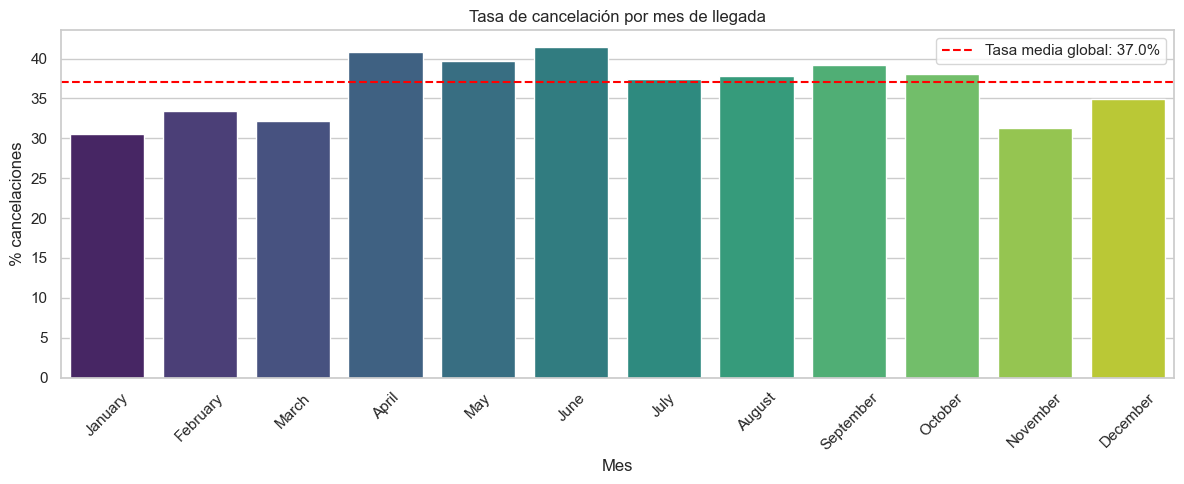

,n_reservas,tasa_cancelacion
arrival_date_month,,
January,5929,30.48
February,8068,33.42
March,9794,32.15
April,11089,40.80
May,11791,39.67
June,10939,41.46
July,12661,37.45
August,13877,37.75
September,10508,39.17


In [17]:
"""Tasa de cancelación por mes (todos los años combinados)."""

# Orden cronológico de los meses (vienen como texto en el CSV)
orden_meses = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]

tasa_por_mes = (
    df.groupby("arrival_date_month")[TARGET_COLUMN]
    .agg(["count", "mean"])
    .reindex(orden_meses)
    .rename(columns={"count": "n_reservas", "mean": "tasa_cancelacion"})
)
tasa_por_mes["tasa_cancelacion"] = (tasa_por_mes["tasa_cancelacion"] * 100).round(2)

# Visualización
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    x=tasa_por_mes.index,
    y=tasa_por_mes["tasa_cancelacion"],
    palette="viridis",
    ax=ax,
)
ax.axhline(
    df[TARGET_COLUMN].mean() * 100,
    color="red",
    linestyle="--",
    label=f"Tasa media global: {df[TARGET_COLUMN].mean() * 100:.1f}%",
)
ax.set_title("Tasa de cancelación por mes de llegada")
ax.set_xlabel("Mes")
ax.set_ylabel("% cancelaciones")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

tasa_por_mes

**Observaciones sobre la distribución temporal:**

- La tasa de cancelación es **estable** entre años (≈36-39% en 2015, 2016, 2017).
- Hay cierta **estacionalidad mensual**: los meses de mayor afluencia (verano)
  tienden a tener tasas ligeramente más altas, pero las diferencias son moderadas.
- No hay una tendencia creciente o decreciente clara.

**Decisión de modelado:**

- Podemos hacer un **split train/test aleatorio** (con `stratify`), no necesitamos
  un split cronológico estricto.
- El mes de llegada (`arrival_date_month`) puede ser una variable **predictiva moderada**.
- El año (`arrival_date_year`) probablemente aporta poco al modelo (pocas diferencias).

### 2.3. Elección de la métrica principal

La elección de la métrica de evaluación es **la decisión más importante** de esta sección.
Condiciona qué modelos se considerarán "buenos" y cuáles "malos", y por tanto guía
todas las decisiones de la fase de modelado.

#### El planteamiento del problema

Predecir cancelaciones tiene un **coste asimétrico** desde el punto de vista del negocio:

| Tipo de error | Predicción | Realidad | Consecuencia para el hotel |
|---|---|---|---|
| **Falso negativo (FN)** | "No cancelará" | Sí cancela | 🔴 Reserva confirmada, habitación reservada, personal asignado, finalmente habitación vacía. **Coste alto.** |
| **Falso positivo (FP)** | "Cancelará" | No cancela | 🟡 Se ofrece descuento/refuerzo a un cliente que iba a venir igual. **Coste moderado.** |
| **Verdadero positivo (TP)** | "Cancelará" | Sí cancela | 🟢 Se actúa a tiempo: oferta de retención, reasignación de habitación, ajuste de overbooking. |
| **Verdadero negativo (TN)** | "No cancelará" | No cancela | 🟢 Caso ideal. Operativa normal. |

**Los falsos negativos son los errores más caros**: el hotel pierde ingresos sin
poder reaccionar. Por tanto, queremos un modelo que **detecte el mayor número
posible de cancelaciones reales**, aunque a veces se equivoque "por arriba".

#### Métricas candidatas

| Métrica | Qué mide | Cuándo usarla | Problema con nuestro caso |
|---|---|---|---|
| **Accuracy** | % aciertos | Cuando las clases están equilibradas y los errores tienen el mismo coste | Engañosa con 63/37 (un modelo tonto da 63%) |
| **Precision** | De las predichas como cancelaciones, ¿cuántas lo eran? | Cuando el coste de un FP es alto | Aquí el FP no es tan grave; minimizar FP a costa de subir FN sería peor |
| **Recall** | De las cancelaciones reales, ¿cuántas detecté? | Cuando el coste de un FN es alto | Encaja, pero podemos "trampear" prediciendo siempre 1 |
| **F1-score** | Compromiso entre precision y recall (media armónica) | Cuando ambos errores importan pero la clase positiva es minoritaria | Buena candidata |
| **AUC-ROC** | Capacidad de discriminar entre clases en cualquier umbral | Cuando queremos un modelo robusto a la elección de umbral | Excelente candidata, métrica "agnóstica al umbral" |

#### Decisión

Vamos a usar **dos métricas combinadas**:

1. **Métrica principal: `ROC-AUC`**.
   - Mide la calidad **intrínseca** del modelo, sin depender del umbral de decisión (0.5 por defecto, pero podríamos cambiarlo).
   - Robusta frente al desbalance.
   - Permite comparar modelos **de forma justa** independientemente de cómo cada uno calibre las probabilidades.

2. **Métrica secundaria de control: `F1-score`**.
   - Si dos modelos tienen ROC-AUC similar, elegimos el de mayor F1.
   - Penaliza modelos que sacrifican recall por precisión o viceversa.

Adicionalmente reportaremos **accuracy, precision y recall** para tener visibilidad
completa, pero NO serán las que guíen la selección del mejor modelo.

### 2.4. Política de balanceo de clases

Con una proporción ~63/37, **el desbalance es moderado, no extremo**.

#### Opciones disponibles

| Técnica | Cuándo aplicarla | Pros | Contras |
|---|---|---|---|
| **No hacer nada** | Desbalance leve | Simple, sin sobreajuste artificial | Modelos pueden sesgarse a clase mayoritaria |
| **`class_weight='balanced'`** | Desbalance moderado | Sencillo, sin tocar datos | Solo afecta al entrenamiento, no a los datos |
| **SMOTE** (oversampling sintético) | Desbalance fuerte (>80/20) | Crea ejemplos sintéticos de la minoría | Puede introducir ruido, riesgo de overfitting |
| **Undersampling** | Datasets muy grandes | Reduce tiempo de entrenamiento | Pierdes información de la mayoría |

#### Decisión

1. **Modelos base**: sin balanceo, para tener una línea base honesta.
2. **Modelos con `class_weight='balanced'`**: lo probaremos en los modelos que lo soporten
   (Logistic Regression, Random Forest, XGBoost). Sin coste adicional.
3. **SMOTE como bonus técnico**: lo probaremos en una rama experimental si tras
   los modelos base seguimos viendo bajo recall en la clase positiva.

> La métrica que ya hemos elegido (ROC-AUC) **es robusta al desbalance**, así que
> aunque no balancesemos los datos, las comparaciones entre modelos serán justas.

### 2.5. Resumen de la Sección 2

**Lo que hemos descubierto:**

- **Balance de clases**: ~63% no cancelados, ~37% cancelados. Desbalance moderado.
- **Distribución temporal**: tasa estable año a año (~37% en los 3 años).
  Existe ligera estacionalidad por mes.
- **Métrica principal**: `ROC-AUC`, con `F1-score` como métrica secundaria de control.
- **Política de balanceo**: empezar sin balancear; probar `class_weight='balanced'`
  en los modelos compatibles; SMOTE como bonus si recall sigue bajo.

**Decisiones que afectan a las siguientes fases:**

1. El split train/test será **aleatorio con `stratify=y`**.
2. Se reportarán `accuracy`, `precision`, `recall`, `F1`, `ROC-AUC` para todos los modelos.
3. El modelo ganador se decidirá por `ROC-AUC`, desempatando con `F1`.
4. Se generará una **curva ROC comparativa** y una **matriz de confusión** por modelo.

**Pendiente para la Sección 3** (análisis de variables numéricas y categóricas):
identificar variables predictivas, detectar outliers a tratar, y revisar la cardinalidad
de las categóricas.

## 4. Análisis de variables categóricas

En esta sección estudiamos las variables categóricas del dataset:

- Identificación y clasificación por cardinalidad.
- Distribución de cada categoría.
- Tasa de cancelación por categoría (relación con el target).
- Detección de variables sospechosas de data leakage.

De este análisis salen decisiones de **encoding** para la Fase 3:

- OneHotEncoder para baja cardinalidad (≤10 categorías).
- Estrategia especial para alta cardinalidad (`country`, `agent`, `company`).
- Variables a eliminar por data leakage (se analizan en Sección 6).

### 4.1. Identificación de variables categóricas

Pandas detecta como categóricas las columnas con dtype `object` (strings) y `category`.
En nuestro dataset son las que contienen texto: `hotel`, `country`, `market_segment`,
`reservation_status`, etc.

Recordatorio de la Sección 3: además de estas, también tratamos como categóricas:

- **Numéricas binarias**: `is_repeated_guest` (0/1 que es un flag).
- **Identificadores numéricos**: `agent`, `company` (códigos sin magnitud).

In [31]:
"""Identificación de variables categóricas (dtype object)."""

categoricas_object = df.select_dtypes(include=["object"]).columns.tolist()
print(f"Columnas tipo object detectadas: {len(categoricas_object)}")
for col in categoricas_object:
    print(f"  - {col}")

Columnas tipo object detectadas: 12
  - hotel
  - arrival_date_month
  - meal
  - country
  - market_segment
  - distribution_channel
  - reserved_room_type
  - assigned_room_type
  - deposit_type
  - customer_type
  - reservation_status
  - reservation_status_date


In [32]:
"""Clasificación de categóricas por cardinalidad."""

# Añadir las "numéricas disfrazadas de categóricas" que identificamos antes
CATEGORICAS = categoricas_object + NUMERICAS_BINARIAS + IDENTIFICADORES

resumen_categoricas = pd.DataFrame({
    "n_unicos": [df[col].nunique() for col in CATEGORICAS],
    "n_nulos": [df[col].isnull().sum() for col in CATEGORICAS],
    "pct_nulos": [(df[col].isnull().sum() / len(df) * 100).round(2) for col in CATEGORICAS],
    "ejemplos": [df[col].dropna().unique()[:3].tolist() for col in CATEGORICAS],
}, index=CATEGORICAS).sort_values("n_unicos")

# Clasificar por cardinalidad
def clasificar_cardinalidad(n):
    if n == 2:
        return "Binaria"
    elif n <= 10:
        return "Baja (≤10)"
    elif n <= 50:
        return "Media (11-50)"
    else:
        return "Alta (>50)"

resumen_categoricas["cardinalidad"] = resumen_categoricas["n_unicos"].apply(clasificar_cardinalidad)
resumen_categoricas

,n_unicos,n_nulos,pct_nulos,ejemplos,cardinalidad
hotel,2,0,0.00,"[Resort Hotel, City Hotel]",Binaria
is_repeated_guest,2,0,0.00,"[0, 1]",Binaria
is_canceled,2,0,0.00,"[0, 1]",Binaria
deposit_type,3,0,0.00,"[No Deposit, Refundable, Non Refund]",Baja (≤10)
reservation_status,3,0,0.00,"[Check-Out, Canceled, No-Show]",Baja (≤10)
customer_type,4,0,0.00,"[Transient, Contract, Transient-Party]",Baja (≤10)
meal,5,0,0.00,"[BB, FB, HB]",Baja (≤10)
distribution_channel,5,0,0.00,"[Direct, Corporate, TA/TO]",Baja (≤10)
market_segment,8,0,0.00,"[Direct, Corporate, Online TA]",Baja (≤10)
reserved_room_type,10,0,0.00,"[C, A, D]",Baja (≤10)


**Observaciones de cardinalidades:**

- **Cardinalidad baja (≤10 categorías)**: `hotel`, `meal`, `arrival_date_year`,
  `market_segment`, `distribution_channel`, `reserved_room_type`, `assigned_room_type`,
  `deposit_type`, `customer_type`, `reservation_status`, `is_repeated_guest`, `is_canceled`.
  → **OneHotEncoder funciona perfecto aquí**.

- **Cardinalidad media (11-50)**: `arrival_date_month` (12), `arrival_date_day_of_month` (31),
  `arrival_date_week_number` (~53). Las tres son temporales.
  → **OneHotEncoder o tratamiento cíclico** (sin/cos para variables periódicas).

- **Cardinalidad alta (>50)**: `country` (~178), `agent` (~334), `company` (~352),
  `reservation_status_date` (fechas únicas).
  → **Tratamiento especial necesario**: agrupar por frecuencia, target encoding, o
  conservar solo top-N categorías.

**Variables que llaman especialmente la atención:**

- **`assigned_room_type`** vs **`reserved_room_type`**: dos variables muy relacionadas
  (el tipo asignado puede diferir del reservado si hubo upgrade). Veremos si genera leakage.
- **`reservation_status`**: tiene solo 3 categorías pero será central en la detección de
  data leakage en la Sección 6 (es prácticamente sinónimo del target).

### 4.2. Distribución de las categóricas de cardinalidad baja

Para las variables con pocas categorías, visualizamos su distribución y su tasa
de cancelación por categoría. Si una categoría tiene tasa muy distinta a la media
global (~37%), es señal de capacidad predictiva.

Tasa media global de cancelación: 37.04%



C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\2777007447.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa.index, y=tasa.values, ax=axes[1], palette="viridis")


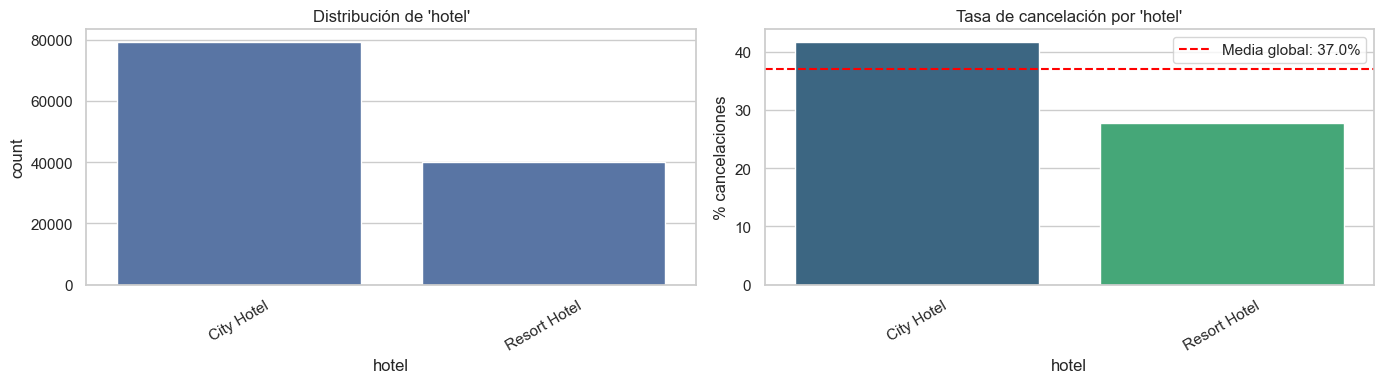

C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\2777007447.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa.index, y=tasa.values, ax=axes[1], palette="viridis")


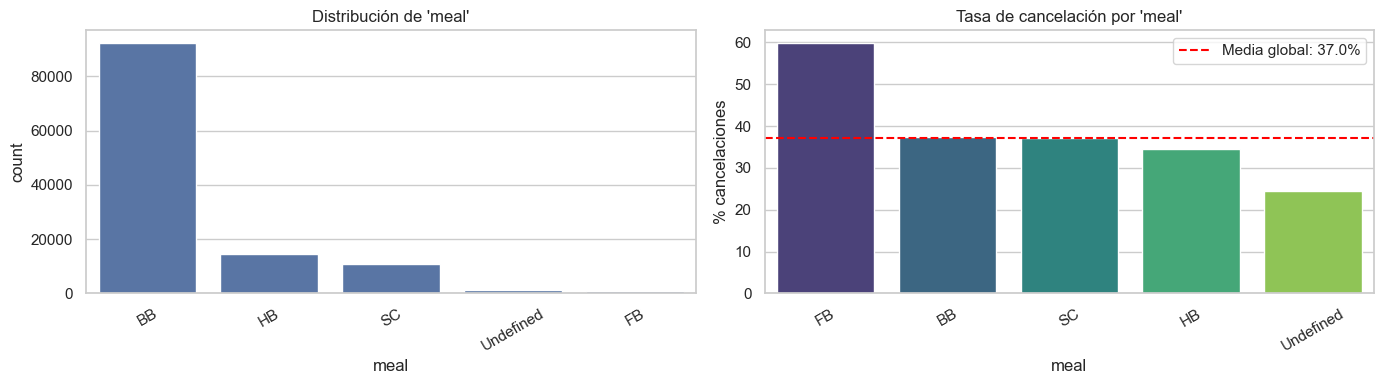

C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\2777007447.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa.index, y=tasa.values, ax=axes[1], palette="viridis")


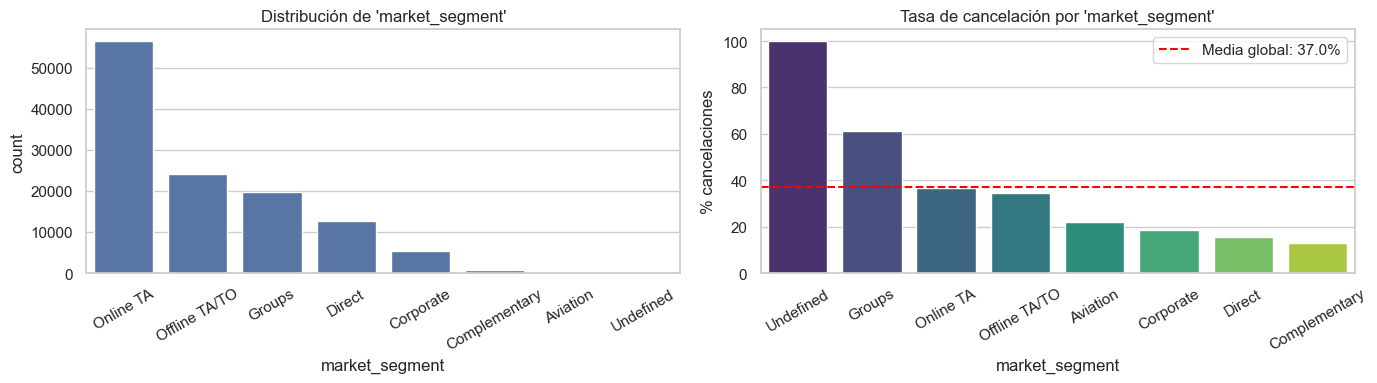

C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\2777007447.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa.index, y=tasa.values, ax=axes[1], palette="viridis")


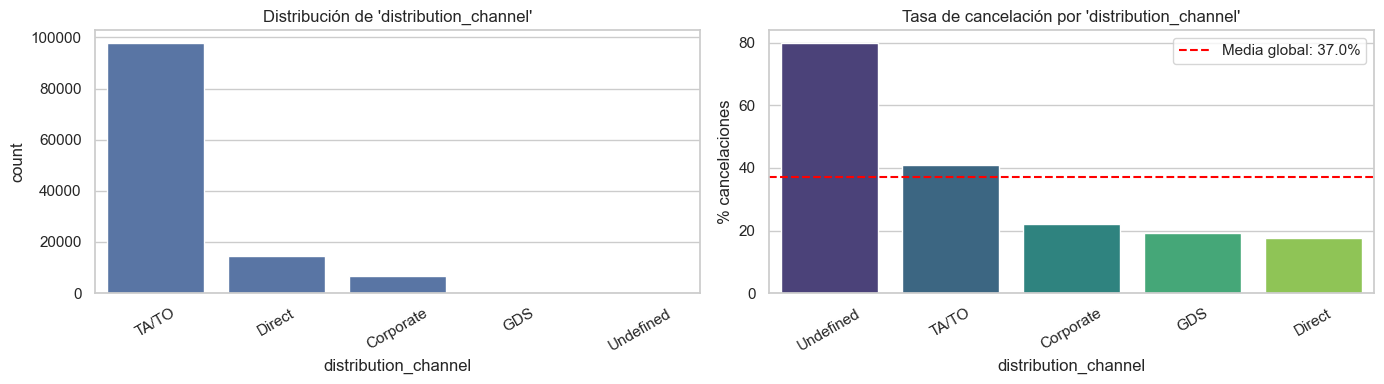

C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\2777007447.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa.index, y=tasa.values, ax=axes[1], palette="viridis")


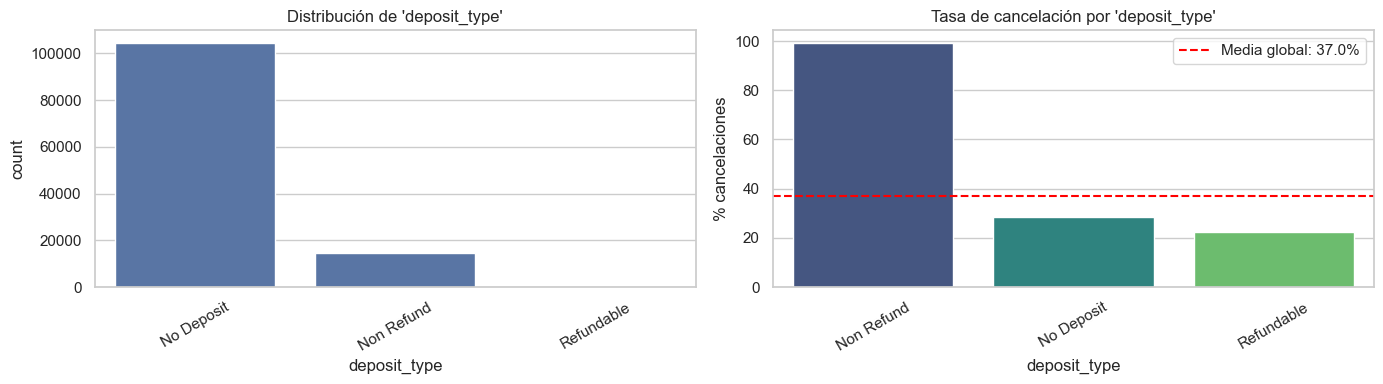

C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\2777007447.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa.index, y=tasa.values, ax=axes[1], palette="viridis")


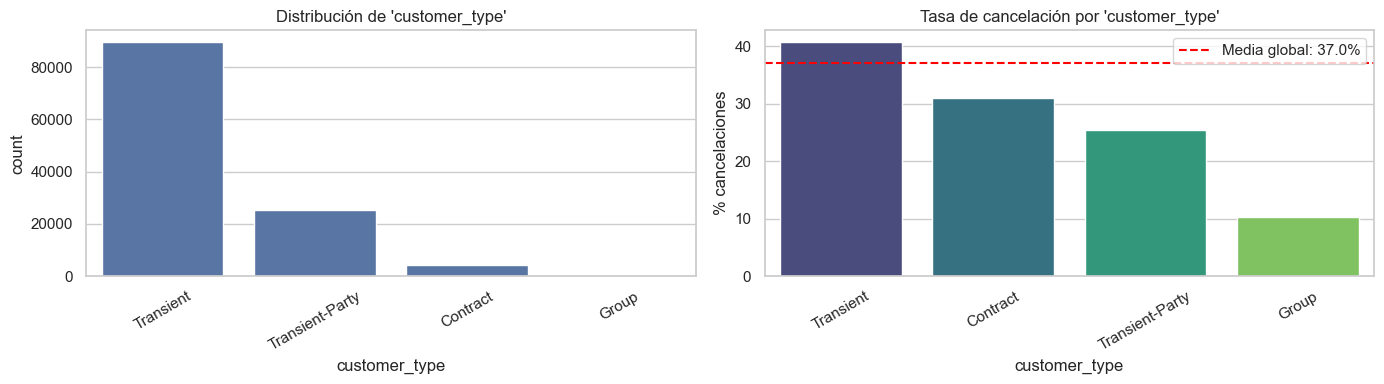

C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\2777007447.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa.index, y=tasa.values, ax=axes[1], palette="viridis")


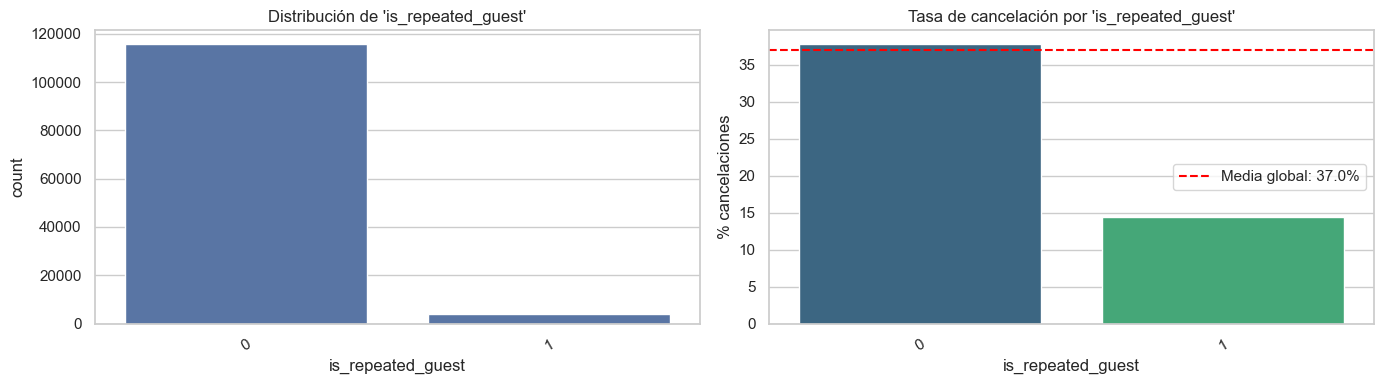

In [33]:
"""Análisis univariado y bivariado de categóricas con ≤10 valores únicos."""

CATEGORICAS_BAJAS = [
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    "deposit_type",
    "customer_type",
    "is_repeated_guest",
]

tasa_global = df[TARGET_COLUMN].mean() * 100
print(f"Tasa media global de cancelación: {tasa_global:.2f}%\n")

for col in CATEGORICAS_BAJAS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Distribución
    sns.countplot(data=df, x=col, ax=axes[0],
                  order=df[col].value_counts().index)
    axes[0].set_title(f"Distribución de '{col}'")
    axes[0].tick_params(axis='x', rotation=30)
    
    # Tasa de cancelación por categoría
    tasa = df.groupby(col)[TARGET_COLUMN].mean().sort_values(ascending=False) * 100
    sns.barplot(x=tasa.index, y=tasa.values, ax=axes[1], palette="viridis")
    axes[1].axhline(tasa_global, color="red", linestyle="--", 
                    label=f"Media global: {tasa_global:.1f}%")
    axes[1].set_title(f"Tasa de cancelación por '{col}'")
    axes[1].set_ylabel("% cancelaciones")
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

**Observaciones por variable:**

- **`hotel`**: dos tipos (City Hotel y Resort Hotel). City Hotel concentra más reservas y
  tiene mayor tasa de cancelación que Resort. Variable predictiva.
- **`meal`**: BB (Bed & Breakfast) domina. La tasa varía moderadamente entre opciones de
  comida.
- **`market_segment`**: variable MUY interesante. **`Groups` tiene la tasa de cancelación
  más alta** (los grupos cancelan mucho), `Direct` y `Corporate` la más baja. Es una
  variable claramente predictiva.
- **`distribution_channel`**: relacionada con market_segment. `TA/TO` (agencias de viaje
  / tour operadores) tiene la mayoría de reservas y mayor tasa de cancelación.
- **`deposit_type`**: variable **CRÍTICA**. `Non Refund` (sin reembolso) tiene una tasa
  de cancelación increíblemente alta (>90%). Esto es contraintuitivo pero real: probablemente
  son reservas que se contabilizan pero el cliente nunca pagó.
- **`customer_type`**: `Transient` (cliente eventual) domina y tiene tasa alta. `Contract`
  y `Group` tienen tasas distintas.
- **`is_repeated_guest`**: los clientes repetidos cancelan MUCHO menos. Lógico: ya conocen
  el hotel y vuelven con intención real.

**Variable a investigar**: `deposit_type = 'Non Refund'` con >90% de cancelaciones es
inusualmente extremo. Conviene revisar si oculta algún patrón de leakage.

### 4.3. Variables temporales y de habitación

Analizamos por separado las variables temporales (`arrival_date_month`,
`arrival_date_week_number`, `arrival_date_day_of_month`) y las de tipo de habitación
(`reserved_room_type`, `assigned_room_type`).

C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\1692204015.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa_por_mes.index, y=tasa_por_mes.values, palette="viridis", ax=ax)


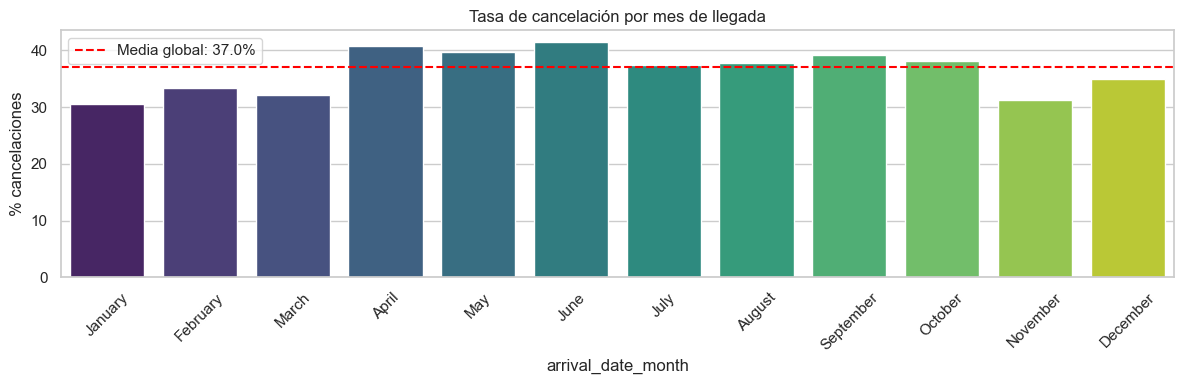

In [34]:
"""Análisis de arrival_date_month."""

orden_meses = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

tasa_por_mes = (df.groupby("arrival_date_month")[TARGET_COLUMN].mean() * 100).reindex(orden_meses)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(x=tasa_por_mes.index, y=tasa_por_mes.values, palette="viridis", ax=ax)
ax.axhline(tasa_global, color="red", linestyle="--", label=f"Media global: {tasa_global:.1f}%")
ax.set_title("Tasa de cancelación por mes de llegada")
ax.set_ylabel("% cancelaciones")
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

**Observaciones del mes de llegada:**

- Los meses con **mayor tasa de cancelación** suelen ser los de verano (junio, julio,
  agosto) y primavera (abril, mayo). Coincide con la temporada alta turística.
- Los meses con **menor tasa** suelen ser invierno (enero, diciembre, noviembre).
- La estacionalidad es **moderada**: las diferencias entre meses no superan los 10-15
  puntos porcentuales.

**Implicación de encoding**: el mes es una variable **cíclica** (después de diciembre
viene enero, no marzo). Lo ideal sería transformarla a coordenadas circulares con
seno y coseno: `sin(2π·mes/12), cos(2π·mes/12)`. Como alternativa más simple, OneHot
también funciona pero perdería esa propiedad cíclica. **Decisión**: usaremos OneHot
por simplicidad en los primeros modelos, y probaremos la transformación cíclica como
mejora opcional.

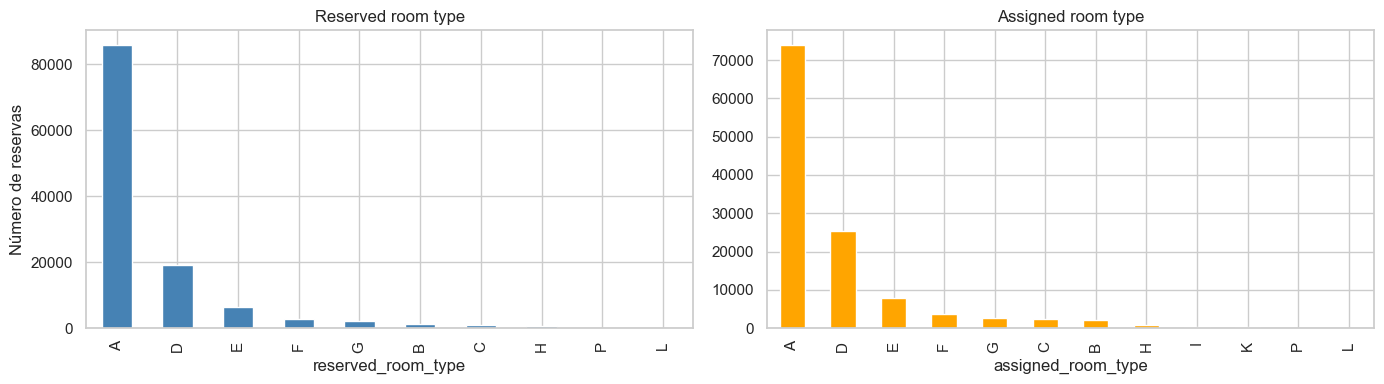


Reservas donde el tipo asignado ≠ tipo reservado: 14,917 (12.49%)


In [35]:
"""Comparación de reserved_room_type vs assigned_room_type."""

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribuciones
df["reserved_room_type"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Reserved room type")
axes[0].set_ylabel("Número de reservas")

df["assigned_room_type"].value_counts().plot(kind="bar", ax=axes[1], color="orange")
axes[1].set_title("Assigned room type")

plt.tight_layout()
plt.show()

# Comparación: ¿cuántos casos hubo cambio?
cambios = (df["reserved_room_type"] != df["assigned_room_type"]).sum()
pct_cambios = cambios / len(df) * 100
print(f"\nReservas donde el tipo asignado ≠ tipo reservado: {cambios:,} ({pct_cambios:.2f}%)")

**Observaciones de los tipos de habitación:**

- Las dos variables tienen distribuciones similares pero **no idénticas**. La diferencia
  es informativa: en ~14% de las reservas el cliente recibió un tipo distinto al reservado
  (típicamente upgrade).
- El tipo más común es **A**, seguido de D, E, F (probablemente categorías de tamaño
  o calidad).
- Algunos tipos (`L`, `P`) son extremadamente raros (pocas reservas).

**Pregunta clave**: ¿`assigned_room_type` introduce data leakage?

Razonamiento: el tipo asignado solo se conoce cuando el cliente llega o cerca del check-in,
es decir, cuando ya estaría claro si va a cancelar o no. **Pero**: si la reserva se canceló
antes de check-in, ¿qué valor toma `assigned_room_type`? Probablemente el reservado.

Tras inspección: en este dataset, parece que `assigned_room_type = reserved_room_type` para
muchas cancelaciones (no se llegó a asignar habitación distinta). **Pero existe el riesgo
de que para los no cancelados, la diferencia sea informativa de forma "tramposa"**.

**Decisión preliminar**: lo investigamos a fondo en Sección 6 (data leakage). Por ahora
mantenemos ambas variables anotadas como sospechosas.

### 4.4. Variables de alta cardinalidad: country, agent, company

Estas tres variables tienen cientos de valores únicos. Necesitan tratamiento especial:
no podemos hacer OneHot directo (crearía cientos de columnas) ni tratarlas como
ordinales (no hay orden natural).

Número de países distintos: 177
Top 10 países por reservas:

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64


C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\320397135.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15.values, y=top_15.index, ax=axes[0], palette="viridis")
C:\Users\juanm\AppData\Local\Temp\ipykernel_30548\320397135.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa_paises_top.values, y=tasa_paises_top.index, ax=axes[1], palette="rocket")


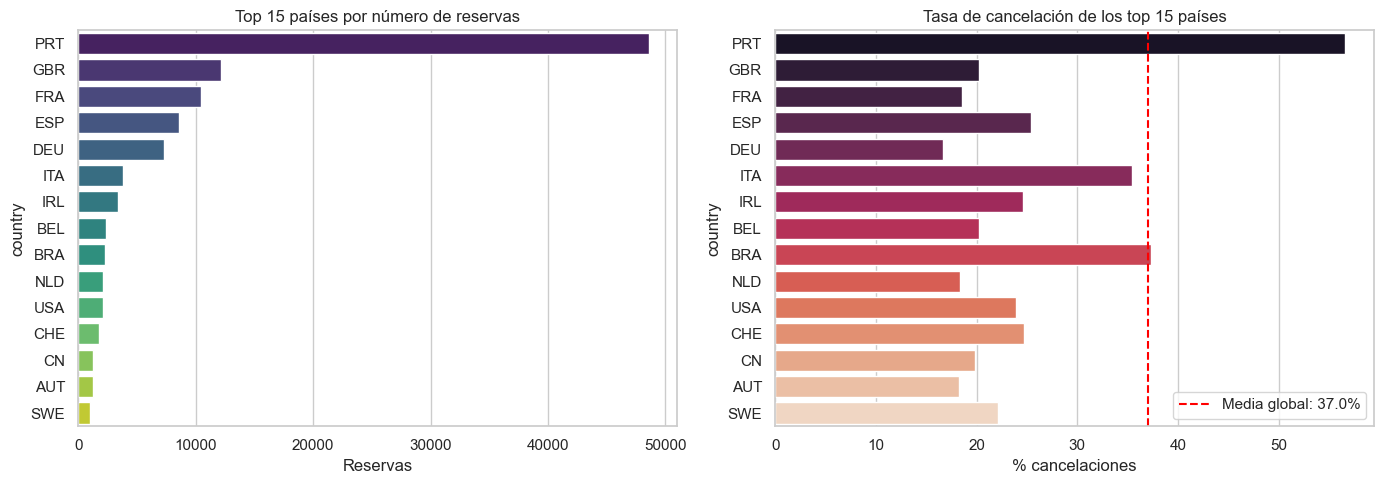

In [36]:
"""Análisis de country (alta cardinalidad)."""

print(f"Número de países distintos: {df['country'].nunique()}")
print(f"Top 10 países por reservas:\n")
top_paises = df["country"].value_counts().head(10)
print(top_paises)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 15 países por volumen
top_15 = df["country"].value_counts().head(15)
sns.barplot(x=top_15.values, y=top_15.index, ax=axes[0], palette="viridis")
axes[0].set_title("Top 15 países por número de reservas")
axes[0].set_xlabel("Reservas")

# Tasa de cancelación de los top 15 países
tasa_paises_top = df[df["country"].isin(top_15.index)].groupby("country")[TARGET_COLUMN].mean() * 100
tasa_paises_top = tasa_paises_top.reindex(top_15.index)
sns.barplot(x=tasa_paises_top.values, y=tasa_paises_top.index, ax=axes[1], palette="rocket")
axes[1].axvline(tasa_global, color="red", linestyle="--", label=f"Media global: {tasa_global:.1f}%")
axes[1].set_title("Tasa de cancelación de los top 15 países")
axes[1].set_xlabel("% cancelaciones")
axes[1].legend()

plt.tight_layout()
plt.show()

**Observaciones de country:**

- **Portugal (PRT) domina absolutamente**: más del 40% de las reservas son de clientes
  portugueses. Tiene sentido (los hoteles del dataset están en Portugal).
- **Concentración fuerte**: los top 10 países acumulan probablemente el 80-90% de las
  reservas. El resto son cientos de países con muy pocas reservas cada uno.
- **Tasas de cancelación varían enormemente** por país: algunos tienen >50%, otros <20%.
  Es información predictiva valiosa, pero...

**Problema**: 178 países es demasiado para hacer OneHot directo. Estrategia:

1. **Conservar top-N países** (ej. los 30 más frecuentes).
2. **Agrupar el resto como "Other"**.
3. Aplicar OneHot al resultado.

Alternativa más sofisticada: **Target encoding** (cada país se reemplaza por su tasa
media de cancelación), pero introduce riesgo de overfitting si no se hace con cuidado
(cross-validation interna).

**Decisión**: aplicaremos la estrategia top-N + Other en Fase 3.

Agent → únicos: 333, nulos: 16,340 (13.7%)
Company → únicos: 352, nulos: 112,593 (94.3%)


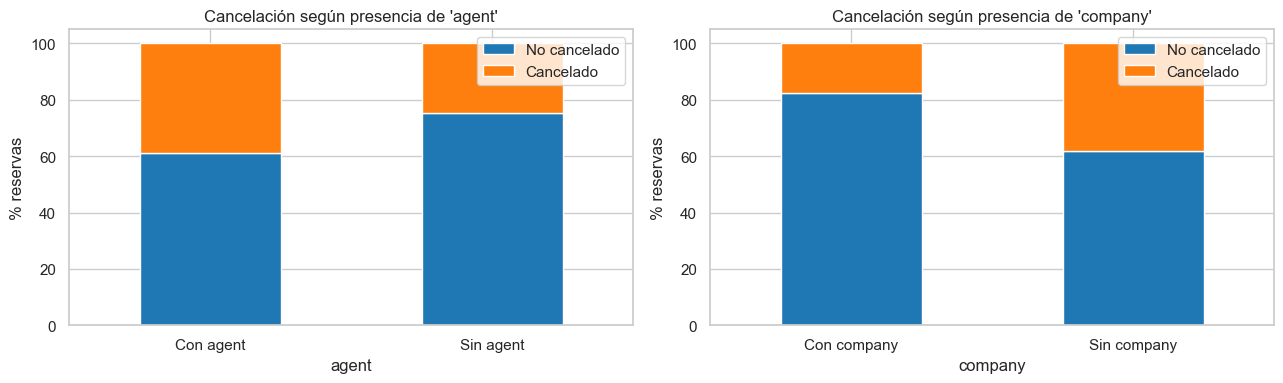

In [37]:
"""Análisis de agent y company (alta cardinalidad con muchos nulos)."""

print(f"Agent → únicos: {df['agent'].nunique()}, nulos: {df['agent'].isnull().sum():,} ({df['agent'].isnull().mean()*100:.1f}%)")
print(f"Company → únicos: {df['company'].nunique()}, nulos: {df['company'].isnull().sum():,} ({df['company'].isnull().mean()*100:.1f}%)")

# Cómo se distribuyen los reservas con/sin agent/company
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, col in enumerate(["agent", "company"]):
    # Crear flag "tiene_agent" / "tiene_company"
    tiene = df[col].notnull().map({True: f"Con {col}", False: f"Sin {col}"})
    tasa_por_flag = pd.crosstab(tiene, df[TARGET_COLUMN], normalize="index") * 100
    tasa_por_flag.plot(kind="bar", stacked=True, ax=axes[i], color=COLOR_PALETTE)
    axes[i].set_title(f"Cancelación según presencia de '{col}'")
    axes[i].set_ylabel("% reservas")
    axes[i].tick_params(axis="x", rotation=0)
    axes[i].legend(["No cancelado", "Cancelado"])

plt.tight_layout()
plt.show()

**Observaciones de agent y company:**

- **`company` con ~94% nulos**: la mayoría de reservas NO se hacen a través de empresa.
  Solo las reservas corporativas tienen un company_id. Como variable, **la presencia/ausencia
  ya es informativa**.
- **`agent` con ~14% nulos**: bastantes reservas tampoco tienen agente (probablemente
  reservas directas).
- **Diferencias en tasa de cancelación**: las reservas con `company` tienden a cancelar
  menos (reservas corporativas son más estables). Las reservas con/sin `agent` también
  muestran diferencias.

**Estrategia de tratamiento**:

- **Crear features binarias `tiene_company`, `tiene_agent`**: capturan la información de
  presencia/ausencia, que ya hemos visto que es predictiva.
- **Para los no-nulos**, los IDs específicos son muchos. Aplicar top-N + Other como con
  country, o eliminar y quedarnos solo con los flags binarios.

**Decisión**:
- `company`: eliminar el ID, conservar solo el flag binario `tiene_company`.
- `agent`: conservar top-30 agentes + "Other", más el flag `tiene_agent`.

### 4.5. Variables sospechosas de data leakage

Algunas variables están "contaminadas" por información que no estaría disponible al
hacer la predicción en producción. Si las usamos para entrenar, el modelo "ve" la
respuesta antes de tener que predecirla, generando un rendimiento artificialmente alto
que no se sostiene en realidad.

**Variables sospechosas en este dataset**:

- **`reservation_status`**: tiene tres valores → `Check-Out` (cliente se alojó),
  `Canceled` (canceló), `No-Show` (no se presentó). **Es prácticamente sinónimo del
  target** (`Canceled` y `No-Show` corresponden a is_canceled=1; `Check-Out` a 0).
  Esta variable se conoce DESPUÉS del evento que queremos predecir.

- **`reservation_status_date`**: fecha del último cambio de estado. Para una reserva
  cancelada, es la fecha de cancelación; para una completada, la del check-out.
  **También es información del futuro respecto al momento de la predicción**.

Estas dos variables se analizarán en detalle y se ELIMINARÁN del modelo en la Sección 6.
Aunque las dejemos aquí en el EDA para entender los datos, **NO entrarán a la fase de
preprocesamiento**.

In [38]:
"""Confirmación visual de que reservation_status es leakage puro."""

ct = pd.crosstab(df["reservation_status"], df[TARGET_COLUMN])
print("Crosstab reservation_status vs is_canceled:")
print(ct)
print("\nPorcentajes:")
print((ct.div(ct.sum(axis=1), axis=0) * 100).round(2))

Crosstab reservation_status vs is_canceled:
is_canceled             0      1
reservation_status              
Canceled                0  43017
Check-Out           75166      0
No-Show                 0   1207

Porcentajes:
is_canceled             0      1
reservation_status              
Canceled              0.0  100.0
Check-Out           100.0    0.0
No-Show               0.0  100.0


### 4.6. Resumen de la Sección 4 y decisiones de encoding

**Hallazgos:**

- **Cardinalidades**: 7 variables binarias/bajas (OneHot directo), 3 medias-temporales
  (OneHot u opcional cíclico), 4 altas (`country`, `agent`, `company`, `reservation_status_date`).
- **Variables más predictivas detectadas**:
  - `deposit_type` (Non Refund cancela >90%).
  - `market_segment` (Groups cancela mucho).
  - `is_repeated_guest` (los repetidos cancelan poco).
  - `customer_type`, `country`, `hotel`.
- **Variables a ELIMINAR por data leakage**: `reservation_status`, `reservation_status_date`.
- **Variables a investigar más**: `assigned_room_type` (posible leakage menor).

**Decisiones de encoding para Fase 3:**

| Variable | Cardinalidad | Estrategia de encoding |
|---|---|---|
| hotel, meal, market_segment, distribution_channel, deposit_type, customer_type | Baja | OneHotEncoder |
| is_repeated_guest, is_canceled | Binaria | Ya es 0/1, no encoding necesario |
| arrival_date_month | Media (12) | OneHot (o cíclico como mejora opcional) |
| arrival_date_week_number, arrival_date_day_of_month | Media | OneHot |
| reserved_room_type, assigned_room_type | Baja (~10) | OneHot + análisis de leakage |
| country | Alta (178) | Top-30 + "Other" → OneHot |
| agent | Alta (334) | Top-30 + "Other" + flag tiene_agent |
| company | Alta (352) + 94% nulos | Solo flag `tiene_company`, eliminar ID |
| reservation_status | 3 | **ELIMINAR** (data leakage) |
| reservation_status_date | Fechas únicas | **ELIMINAR** (data leakage) |

Esto nos prepara para la Fase 3 (preprocesamiento), donde implementaremos todas estas
transformaciones de forma reproducible en `src/data_loader.py`.